In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn_extra.cluster import KMedoids
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
import skfuzzy as fuzzy
from skfuzzy import control as ctrl

warnings.filterwarnings('ignore')
plt.style.use('ggplot')

path = r'D:\data mining project\archive\CC GENERAL.csv'
df = pd.read_csv(path)
print(f"Dataset Loaded. Nulls found: {df.isnull().sum().sum()}")

Dataset Loaded. Nulls found: 314


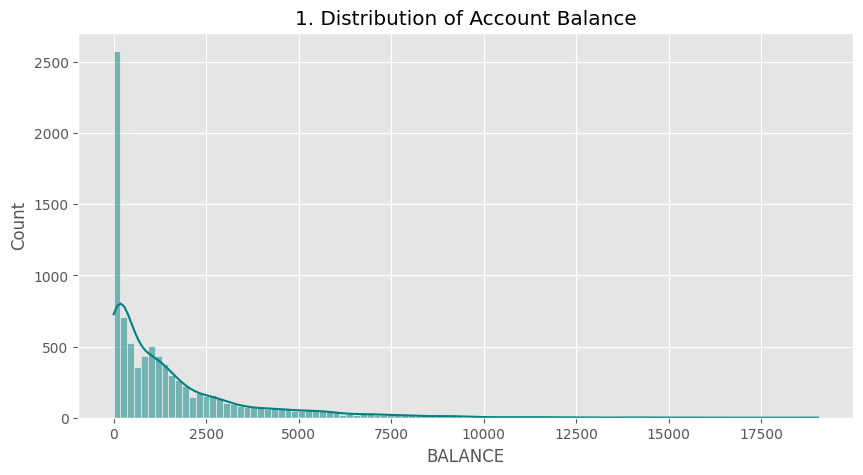

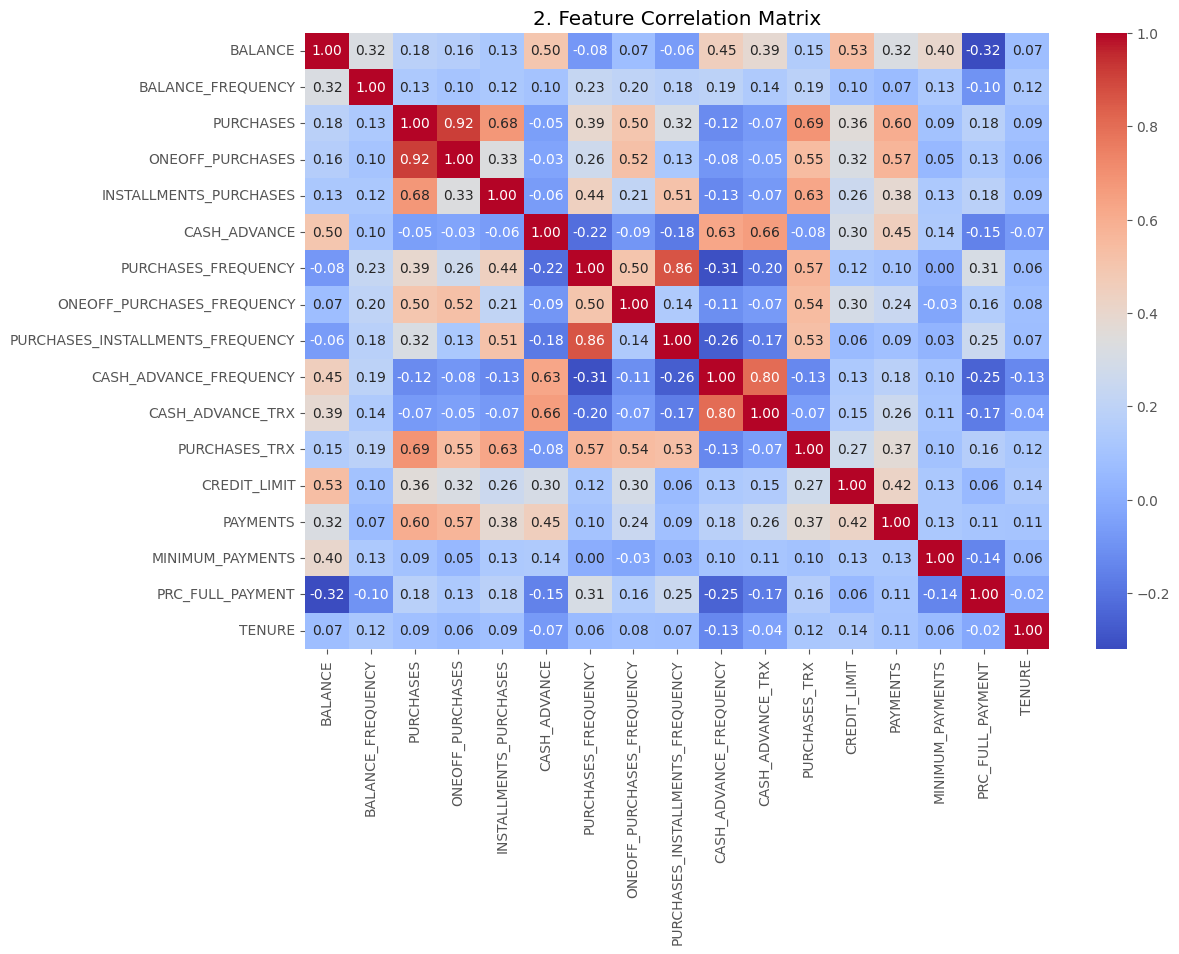

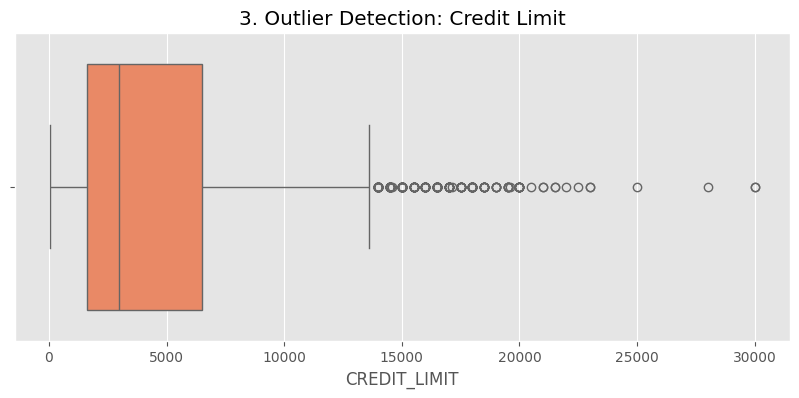

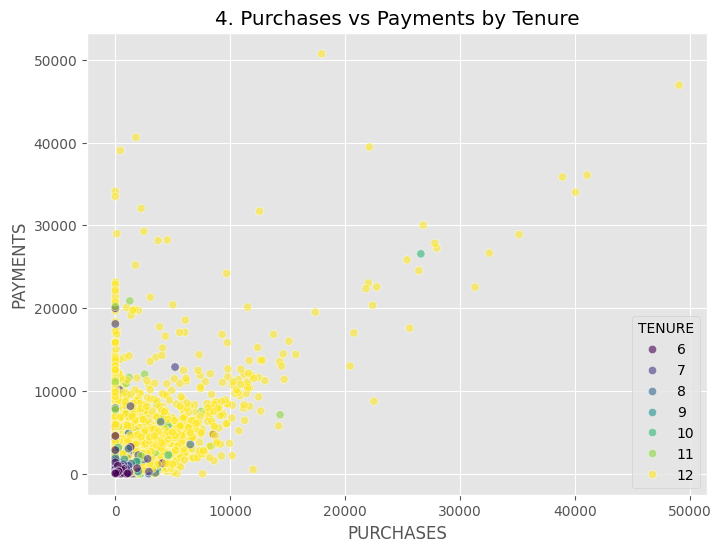

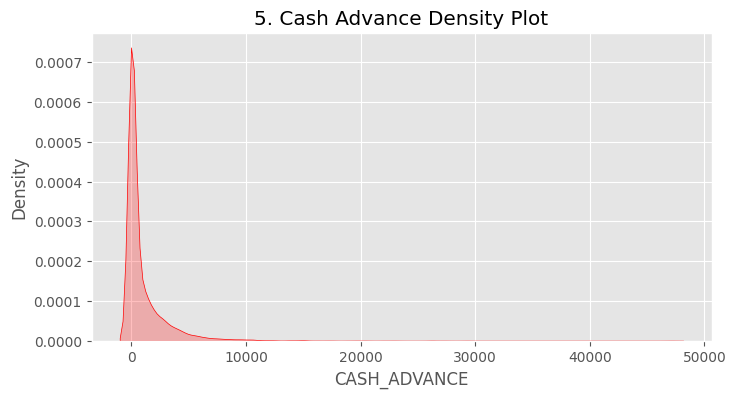

In [6]:
# Cell 2: Exploratory Data Analysis (EDA)
# 1. توزيع الرصيد (Skewness Analysis)
plt.figure(figsize=(10, 5))
sns.histplot(df['BALANCE'], kde=True, color='teal')
plt.title('1. Distribution of Account Balance')
plt.show()
# رؤية تحليلية: البيانات تظهر انحرافاً موجباً قوياً (Positive Skewness).
# هذا يعني أن معظم العملاء لديهم أرصدة منخفضة، بينما تتركز القوة المالية في فئة قليلة "VIP".

# 2. مصفوفة الارتباط (Heatmap)
plt.figure(figsize=(12, 8))
corr_matrix = df.drop('CUST_ID', axis=1).corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('2. Feature Correlation Matrix')
plt.show()
# رؤية تحليلية: نلاحظ ارتباطاً كبيراً (0.91) بين PURCHASES و ONEOFF_PURCHASES.
# هذا يشير إلى وجود "تكرار معلوماتي"؛ فالعملاء الذين يشترون كثيراً يميلون للقيام بعمليات شراء لمرة واحدة بمبالغ كبيرة.

# 3. الكشف عن القيم الشاذة (Outlier Detection)
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['CREDIT_LIMIT'], color='coral')
plt.title('3. Outlier Detection: Credit Limit')
plt.show()
# رؤية تحليلية: هناك قيم شاذة كثيرة تتجاوز 15,000. هذه القيم تمثل بطاقات النخبة، 
# لذا سنعتمد تقنية "Capping" بدلاً من الحذف للحفاظ على هذه الشريحة الهامة.

# 4. العلاقة بين المشتريات والمدفوعات
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='PURCHASES', y='PAYMENTS', hue='TENURE', palette='viridis', alpha=0.6)
plt.title('4. Purchases vs Payments by Tenure')
plt.show()
# رؤية تحليلية: العملاء الجدد (Tenure أقل) يميلون لإنفاق أقل مقارنة بالقدامى، مما يظهر أهمية "الولاء".

# 5. تكرار السحب النقدي (Cash Advance)
plt.figure(figsize=(8, 4))
sns.kdeplot(df['CASH_ADVANCE'], fill=True, color='red')
plt.title('5. Cash Advance Density Plot')
plt.show()
# رؤية تحليلية: الاعتماد على السحب النقدي منخفض جداً لدى الأغلبية، مما يشير إلى أن البطاقات تُستخدم للشراء أكثر من التسييل المالي.

In [7]:
# Cell 3: Robust Preprocessing
# 1. حذف العمود غير الرقمي
df_clean = df.drop('CUST_ID', axis=1)

# 2. ملء القيم المفقودة بالتعيين المباشر (أكثر أماناً من inplace)
df_clean['MINIMUM_PAYMENTS'] = df_clean['MINIMUM_PAYMENTS'].fillna(df_clean['MINIMUM_PAYMENTS'].median())
df_clean['CREDIT_LIMIT'] = df_clean['CREDIT_LIMIT'].fillna(df_clean['CREDIT_LIMIT'].median())

# 3. التأكد من عدم وجود أي قيم مفقودة متبقية في أي عمود آخر
df_clean = df_clean.fillna(df_clean.median())

# 4. معالجة القيم الشاذة (Capping)
for col in df_clean.columns:
    upper_limit = df_clean[col].quantile(0.95)
    df_clean[col] = np.where(df_clean[col] > upper_limit, upper_limit, df_clean[col])

# 5. التقييس (Scaling)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clean)

# فحص نهائي للـ NaNs قبل الـ PCA
if np.isnan(X_scaled).any():
    print("Warning: NaNs still present! Cleaning again...")
    X_scaled = np.nan_to_num(X_scaled)

# 6. البونص: PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Preprocessing and PCA completed successfully without NaNs.")

Preprocessing and PCA completed successfully without NaNs.


Optimal clusters based on Silhouette: 2


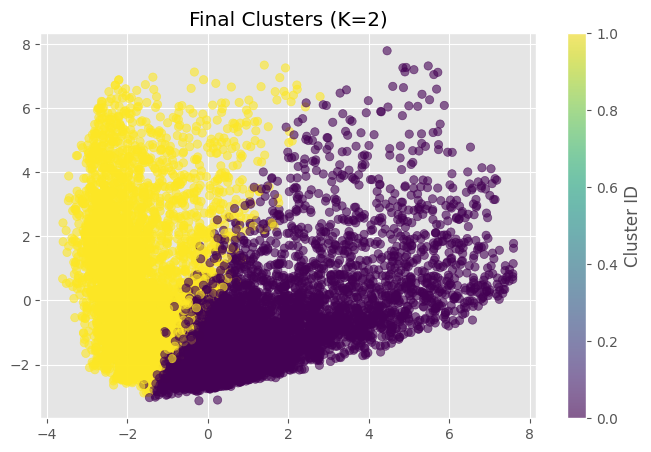

In [8]:
# Cell 4: K-Medoids
# سنستخدم X_scaled للتدريب الفعلي (أكثر دقة) و X_pca للرسم فقط
kmedoids_range = range(2, 6)
scores = []

for k in kmedoids_range:
    model = KMedoids(n_clusters=k, random_state=42).fit(X_scaled)
    scores.append(silhouette_score(X_scaled, model.labels_))

best_k = kmedoids_range[np.argmax(scores)]
print(f"Optimal clusters based on Silhouette: {best_k}")

final_kmed = KMedoids(n_clusters=best_k, random_state=42).fit(X_scaled)
df['Cluster'] = final_kmed.labels_

# الرسم
plt.figure(figsize=(8, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['Cluster'], cmap='viridis', alpha=0.6)
plt.title(f'Final Clusters (K={best_k})')
plt.colorbar(label='Cluster ID')
plt.show()

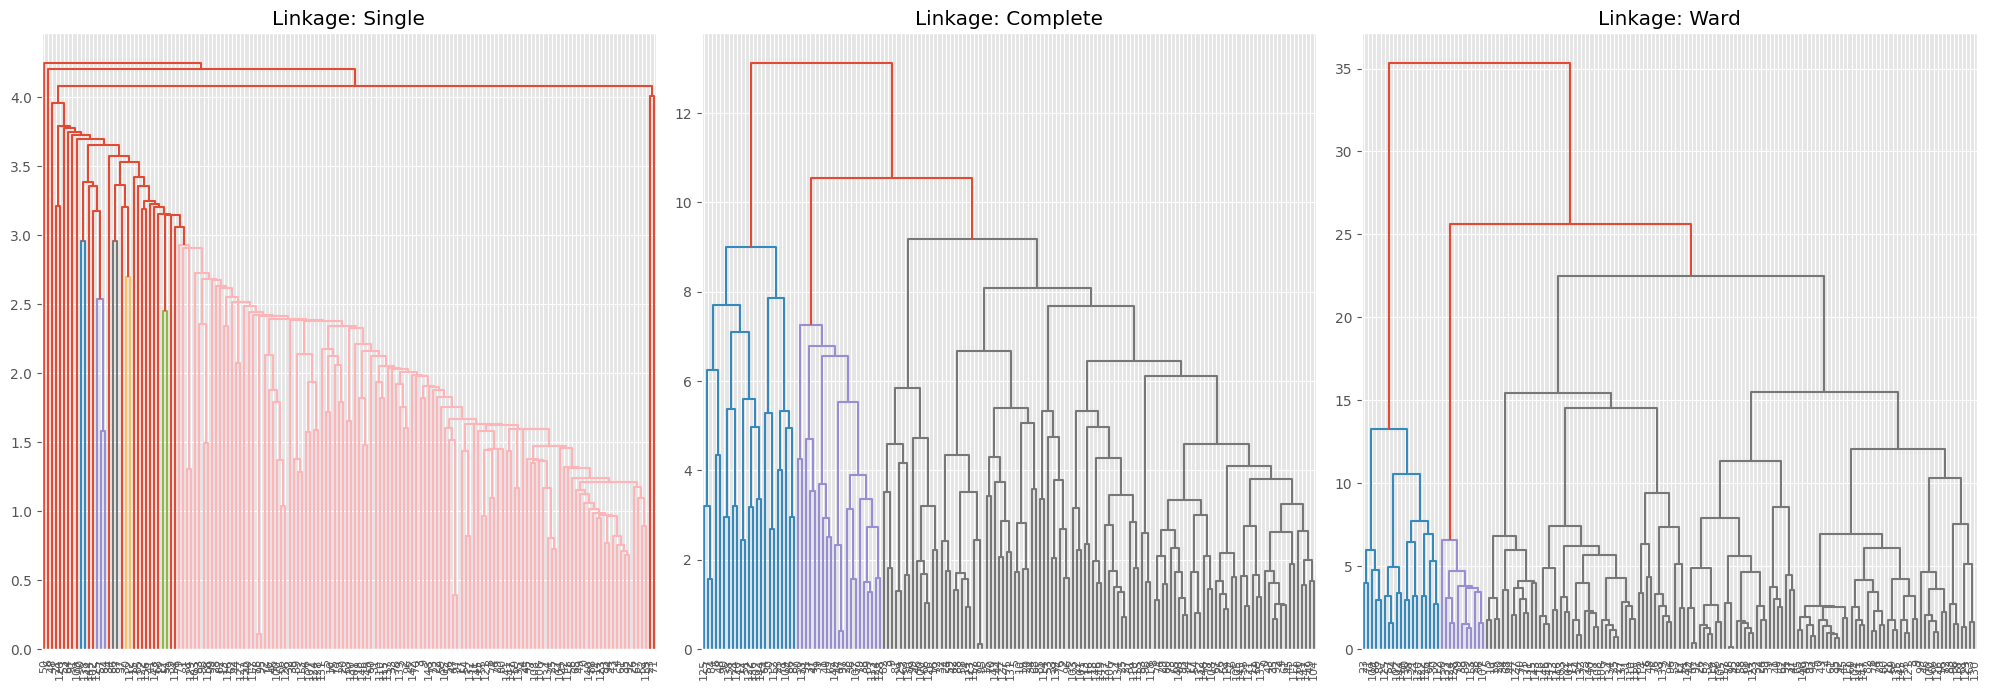

In [9]:
# Cell 5: Hierarchical Clustering Comparison
from scipy.cluster.hierarchy import dendrogram, linkage

# سنستخدم عينة (Subset) من البيانات للرسم ليكون الـ Dendrogram واضحاً
data_subset = X_scaled[:150] 

# 1. تجربة 3 طرق للربط (Linkage Methods) كما هو مطلوب
methods = ['single', 'complete', 'ward']
plt.figure(figsize=(20, 7))

for i, method in enumerate(methods):
    plt.subplot(1, 3, i+1)
    Z = linkage(data_subset, method=method)
    dendrogram(Z, leaf_rotation=90, leaf_font_size=8)
    plt.title(f"Linkage: {method.capitalize()}")

plt.tight_layout()
plt.show()

# ملاحظة تحليلية للمناقشة:
# طريقة 'Ward' هي الأكثر توازناً في توزيع المجموعات، بينما 'Single' تظهر ظاهرة chaining.

In [10]:
# Cell 6: Fuzzy Logic with 9 Strategic Rules
# تعريف المتغيرات (Antecedents & Consequent)
purch_freq = ctrl.Antecedent(np.arange(0, 1.1, 0.1), 'purch_freq')
cluster_in = ctrl.Antecedent(np.arange(0, 3, 1), 'cluster')
credit_worthiness = ctrl.Consequent(np.arange(0, 101, 1), 'credit_worthiness')

# تعريف دوال العضوية (Membership Functions)
purch_freq.automf(3, names=['low', 'medium', 'high'])

# تقسيم الـ Clusters لثلاث فئات منطقية
cluster_in['economizer'] = fuzzy.trimf(cluster_in.universe, [0, 0, 1])
cluster_in['installment'] = fuzzy.trimf(cluster_in.universe, [0, 1, 2])
cluster_in['vip'] = fuzzy.trimf(cluster_in.universe, [1, 2, 2])

# مخرجات الجدارة الائتمانية
credit_worthiness['low'] = fuzzy.trimf(credit_worthiness.universe, [0, 0, 45])
credit_worthiness['average'] = fuzzy.trimf(credit_worthiness.universe, [35, 60, 85])
credit_worthiness['prime'] = fuzzy.trimf(credit_worthiness.universe, [75, 100, 100])

# بناء القواعد الـ 9 (9 Rules)
rules = [
    ctrl.Rule(cluster_in['vip'] & purch_freq['high'], credit_worthiness['prime']),
    ctrl.Rule(cluster_in['vip'] & purch_freq['medium'], credit_worthiness['prime']),
    ctrl.Rule(cluster_in['vip'] & purch_freq['low'], credit_worthiness['average']),
    ctrl.Rule(cluster_in['installment'] & purch_freq['high'], credit_worthiness['prime']),
    ctrl.Rule(cluster_in['installment'] & purch_freq['medium'], credit_worthiness['average']),
    ctrl.Rule(cluster_in['installment'] & purch_freq['low'], credit_worthiness['low']),
    ctrl.Rule(cluster_in['economizer'] & purch_freq['high'], credit_worthiness['average']),
    ctrl.Rule(cluster_in['economizer'] & purch_freq['medium'], credit_worthiness['low']),
    ctrl.Rule(cluster_in['economizer'] & purch_freq['low'], credit_worthiness['low']),
]

credit_ctrl = ctrl.ControlSystem(rules)
credit_sim = ctrl.ControlSystemSimulation(credit_ctrl)

print("Fuzzy logic system designed with 9 rules successfully.")

Fuzzy logic system designed with 9 rules successfully.


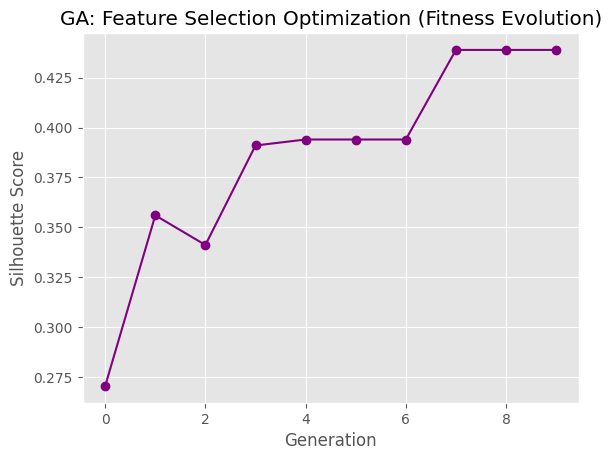

In [11]:
# Cell 7: Full Genetic Algorithm for Feature Selection
def fitness(chromosome):
    selected_indices = [i for i, gene in enumerate(chromosome) if gene == 1]
    if len(selected_indices) < 2: return 0
    # قياس جودة التجميع بناءً على الخصائص المختارة فقط
    return silhouette_score(X_scaled[:1000, selected_indices], final_kmed.labels_[:1000])

# إعدادات الـ GA
pop_size = 12
num_genes = 17 # عدد خصائص البيانات
population = [np.random.randint(0, 2, num_genes) for _ in range(pop_size)]
generations = 10
best_scores = []

for gen in range(generations):
    scores = [fitness(c) for c in population]
    best_scores.append(max(scores))
    
    # Selection (أفضل الأبوين)
    parents = [population[i] for i in np.argsort(scores)[-4:]]
    
    # Crossover & Mutation (إنتاج جيل جديد)
    new_pop = []
    for _ in range(pop_size):
        p1, p2 = parents[np.random.randint(0, 4)], parents[np.random.randint(0, 4)]
        child = np.where(np.random.rand(num_genes) > 0.5, p1, p2) # Crossover
        if np.random.rand() < 0.1: child[np.random.randint(0, num_genes)] ^= 1 # Mutation
        new_pop.append(child)
    population = new_pop

plt.plot(best_scores, marker='o', color='purple')
plt.title("GA: Feature Selection Optimization (Fitness Evolution)")
plt.xlabel("Generation"); plt.ylabel("Silhouette Score")
plt.show()

In [12]:
# Cell 8: Integrated Credit Scoring Pipeline
def run_final_inference(customer_index):
    # 1. الحصول على البيانات الخام كـ DataFrame
    raw_record = df_clean.iloc[[customer_index]]
    
    # 2. التجهيز (Scaling)
    scaled_record = scaler.transform(raw_record)
    
    # 3. توقع المجموعة (Clustering)
    assigned_cluster = final_kmed.predict(scaled_record)[0]
    
    # 4. المنطق الضبابي (Fuzzy Logic)
    # نستخدم خاصية PURCHASES_FREQUENCY من البيانات الخام
    p_freq = raw_record['PURCHASES_FREQUENCY'].values[0]
    
    credit_sim.input['purch_freq'] = p_freq
    credit_sim.input['cluster'] = assigned_cluster
    
    try:
        credit_sim.compute()
        final_score = credit_sim.output['credit_worthiness']
        
        print(f"--- Customer Credit Report ---")
        print(f"Customer Index: {customer_index}")
        print(f"Segment: {['Economizer', 'Installment User', 'VIP'][assigned_cluster]}")
        print(f"Purchasing Frequency: {p_freq:.2f}")
        print(f"Final Credit Score: {final_score:.2f}%")
        return final_score
    except Exception as e:
        print(f"Error calculating score: {e}")

# تجربة نهائية على العميل رقم 5
run_final_inference(5)

--- Customer Credit Report ---
Customer Index: 5
Segment: Economizer
Purchasing Frequency: 0.67
Final Credit Score: 34.07%


34.06632593659008